In [ ]:
# Customer Personality Analysis - Unsupervised Learning Tugas 3

#memasukan library yang diperlukan
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset

In [ ]:
#memasukan dataset yang sudah disediakan
#memisahkan nya dengan pemisah/separator tab (sep='\t) agar atributnya tidak mengumpul di satu kolom
df = pd.read_csv('cpa.csv', sep ='\t')
#mengecek apakah dataset sudah terpisah kebeberapa kolom atau belum
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Dataset sudah masuk dimana yang atribut sebelumnya berkumpul disatu kolom. namun dengan memisahkan nya menggunakan perintah sep='\t'membuat atribut data set terpisah menjadi lebih rapi untuk diolah datanya.

#Step2: lakukan Eksplorasi awal

In [ ]:
#mengecek atribut apa saja yang ada dalam dataset
print(df.info())
#mengecek apakah ada data yang kosong
print(df.isnull().sum())
#mengecek statistik distibusi fitur utama
display (df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


data terdiri dari 2240 data entries dan 29 kolom. dataset terdiri dari data kategorikal (object) dan data numerik (integer dan float). kita juga dapat mengetahui bahwa terdapat missing value yaitu pada data income sebanyak 24 data. dari distribusi fitur utama kita dapat melihat mean, min dan max atribut data.

# Step 3: Identifikasi kolom numerik & kategori

In [ ]:
#identifikasi data kolom kategori
Data_kategori = df.select_dtypes(include=['object']).columns.tolist()
#identifikasi data kolom numerik
Data_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print ("Kolom data kategori = ", Data_kategori)
print ("Kolom data numerik = " ,Data_numerik)

Kolom data kategori =  ['Education', 'Marital_Status', 'Dt_Customer']
Kolom data numerik =  ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


# Step 4: Imputasi missing value

In [ ]:
#mengisi missing value atribut income dengan median karena data income biasanya rentan outliers
df['Income'] = df['Income'].fillna(df['Income'].median())
#mengecek kembali missinng value
print(df.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


Dataset sudah tidak terdapat missing value lagi didalam nya.


# Step 5: Encoding fitur kategori

In [ ]:
#melihat data masing masing kolom dan value counts nya
print('Dt_Customer')
print(df['Dt_Customer'].value_counts())
print('Education')
print(df['Education'].value_counts())
print('Marital_Status')
print(df['Marital_Status'].value_counts())

Dt_Customer
Dt_Customer
31-08-2012    12
12-05-2014    11
14-02-2013    11
12-09-2012    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 663, dtype: int64
Education
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


karena data Dt_Customer merupakan data format tanggal maka atribut ini akan dihapus agar model K-means nanti lebih akurat dan kenapa saya tidak melakukan encoding atribut ini karena setiap data tanggal nya berbeda sehingga hasil encoding atribut nya akan terlalu panjang dan membuat model K-means nanti menjadi tidak akurat.

In [ ]:
#menghapus atribut Dt_Customer
df = df.drop(columns=['Dt_Customer'])
#mengecek apakah atribut tersebut sudah terhapus atau belum
print(df.info())
#melakukan One-hot encoding kolom kategorikal yaitu pada kolom education dan marital_status, hasil dalam bentuk 0 dan 1
Data_Encoding = pd.get_dummies(df, columns=['Education', 'Marital_Status'], dtype=int)
#melihat hasil encoding
print(Data_Encoding)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   i

In [ ]:
#melihat dataset atribut yang baru
print(Data_Encoding.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Year_Birth               2240 non-null   int64  
 2   Income                   2240 non-null   float64
 3   Kidhome                  2240 non-null   int64  
 4   Teenhome                 2240 non-null   int64  
 5   Recency                  2240 non-null   int64  
 6   MntWines                 2240 non-null   int64  
 7   MntFruits                2240 non-null   int64  
 8   MntMeatProducts          2240 non-null   int64  
 9   MntFishProducts          2240 non-null   int64  
 10  MntSweetProducts         2240 non-null   int64  
 11  MntGoldProds             2240 non-null   int64  
 12  NumDealsPurchases        2240 non-null   int64  
 13  NumWebPurchases          2240 non-null   int64  
 14  NumCatalogPurchases     

Data kategorikal sudah diencode dan siap diolah dan kolom data Dt_Customer sudah sepenuhnya terhapus. menjadikan dataset yang sebelumnya terdiri dari 29 kolom menjadi 39 kolom.

#Gabungkan data numerik & hasil encoding

karena sebelumnya saya menggunakan perintah one-hot encoding (pd.get_dummies) maka secara otomatis data numerik dan data hasil encoding akan tergabung.

In [ ]:
#melihat hasil gabungan data numerik dan hasil encoding
display(Data_Encoding)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,0,0,1,0,0,0
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,0,1,0,0,0
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,0,0,1,0,0
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,0,0,1,0,0
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,61223.0,0,1,46,709,43,182,42,...,0,0,0,0,0,1,0,0,0,0
2236,4001,1946,64014.0,2,1,56,406,0,30,0,...,0,1,0,0,0,0,0,1,0,0
2237,7270,1981,56981.0,0,0,91,908,48,217,32,...,0,0,0,0,1,0,0,0,0,0
2238,8235,1956,69245.0,0,1,8,428,30,214,80,...,1,0,0,0,0,0,0,1,0,0


# Step 6: Scaling data

In [ ]:
#memasukan perintah scaling data
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(Data_Encoding)
Data_Scaling = pd.DataFrame(X_minmax, columns=Data_Encoding.columns)
#melihat hasil Scaling data
display(Data_Scaling.head())

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,0.493611,0.621359,0.084832,0.0,0.0,0.585859,0.425318,0.442211,0.316522,0.664093,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.194263,0.592233,0.067095,0.5,0.5,0.383838,0.007368,0.005025,0.003478,0.007722,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.370029,0.699029,0.105097,0.0,0.0,0.262626,0.285332,0.246231,0.073623,0.428571,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.552408,0.883495,0.037471,0.5,0.0,0.262626,0.007368,0.020101,0.011594,0.038610,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.475739,0.854369,0.085065,0.5,0.0,0.949495,0.115874,0.216080,0.068406,0.177606,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


dilakukan scaling data atribut agar berada dalam rentang yang sama yaitu 0 sampai 1


# Step 7: Tentukan jumlah cluster optimal (Elbow + Silhouette)

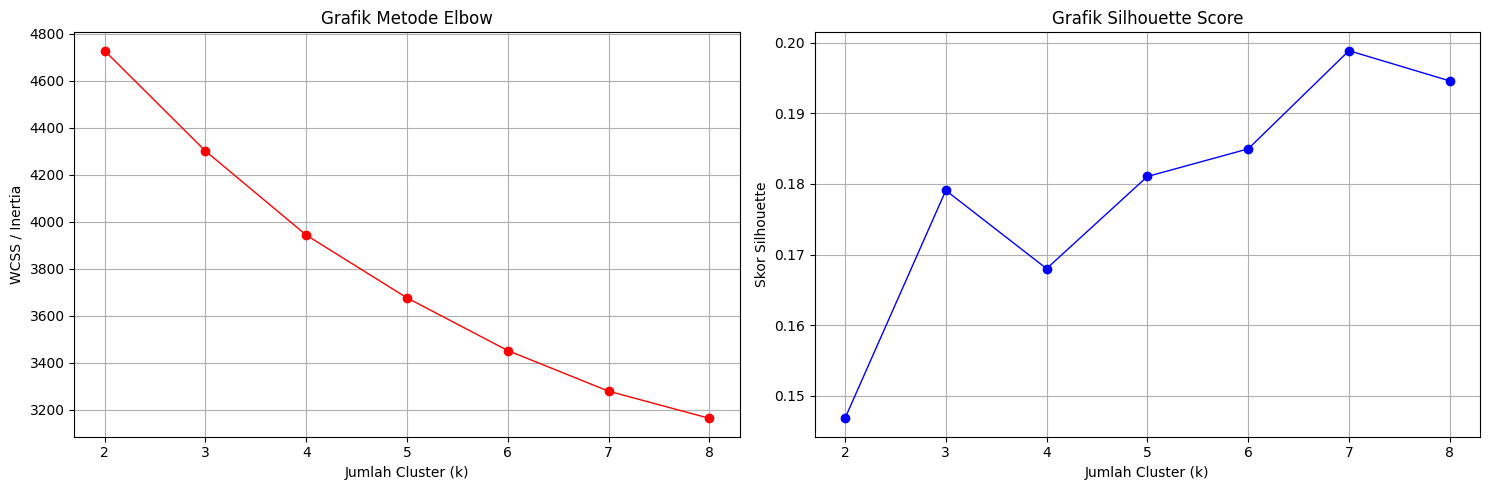

In [ ]:
#Menyiapkan list penampung nilai evaluasi
wcss = []
silhouette_vals = []
K_range = range(2, 9) #Menguji klaster dari 2 sampai 8

#melakukan perulangan untuk menghitung akurasi tiap nilai K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Data_Scaling)

    wcss.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(Data_Scaling, labels))

#menggambar grafik berdampingan
plt.figure(figsize=(15, 5))

#Grafik Kiri: Metode Elbow
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o', color='r', linewidth=1)
plt.title('Grafik Metode Elbow')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)

#Grafik Kanan: Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_vals, marker='o', color='b', linewidth=1)
plt.title('Grafik Silhouette Score')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Skor Silhouette')
plt.grid(True)

plt.tight_layout()
plt.show()

pada grafik metode elbow terlihat garis menukik membentuk sudut pada Klaster ke 3. sedangkan pada grafik silhoutte titik garis tiba tiba meninggi di Klaster ke 3. sehingga saya akan menggunakan k = 3 sebagai nilai k optimalnya.

# Step 8: Pilih k optimal dan klasterisasi

pada tahap ini saya akan menggunakan k = 3 sebagai k optimal nya

In [ ]:
#nilai k optimal
k_optimal = 3
#menggunakan K-Means dengan jumlah klaster yang sudah dipilih
Nilai_Kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
#menyimpan hasil perhitungan ke kolom Klaster
Data_Scaling['Klaster'] = Nilai_Kmeans.fit_predict(Data_Scaling)
#melihat hasil klasterisasi
display(Data_Scaling.head())
#menyalin atribut klaster ke df
Data_Encoding['Klaster'] = Data_Scaling['Klaster']

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Klaster
0,0.493611,0.621359,0.084832,0.0,0.0,0.585859,0.425318,0.442211,0.316522,0.664093,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
1,0.194263,0.592233,0.067095,0.5,0.5,0.383838,0.007368,0.005025,0.003478,0.007722,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
2,0.370029,0.699029,0.105097,0.0,0.0,0.262626,0.285332,0.246231,0.073623,0.428571,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,0.552408,0.883495,0.037471,0.5,0.0,0.262626,0.007368,0.020101,0.011594,0.038610,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
4,0.475739,0.854369,0.085065,0.5,0.0,0.949495,0.115874,0.216080,0.068406,0.177606,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2


Hasil Klasterisasi sudah didapatkan dan dimasukan menjadi atribut/kolom baru di dataset dengan nama 'Klaster'.

In [ ]:
#melihat jumlah pelanggan di masing masing klaster
print(Data_Scaling['Klaster'].value_counts())

Klaster
1    896
2    864
0    480
Name: count, dtype: int64


# Step 9: Visualisasi klaster dengan PCA 2D

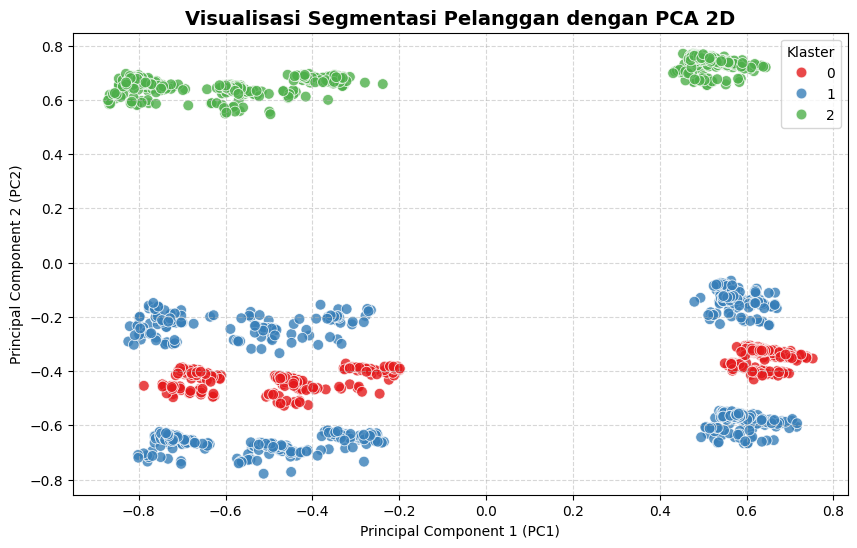

In [ ]:
#memisahkan fitur dari kolom atribut 'Klaster' agar label tidak ikut terhitung dalam PCA
X_for_pca = Data_Scaling.drop(columns=['Klaster'], errors='ignore')
#melakukan reduksi dimensi data menjadi 2 komponen utama
pca = PCA(n_components=2, random_state=42)
pca_hasil = pca.fit_transform(X_for_pca)
#membuat dateframe baru untuk visualisasi PCA
PCA2D = pd.DataFrame(data=pca_hasil, columns=['PC1', 'PC2'])
PCA2D ['Klaster'] = Data_Scaling['Klaster'].values
#Menggambar grafik Scatterplot 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Klaster',
    data=PCA2D,
    palette='Set1',
    s=60,
    alpha=0.8
)
plt.title('Visualisasi Segmentasi Pelanggan dengan PCA 2D', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Klaster', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Step 10: Profiling cluster (rata-rata fitur per cluster)

In [ ]:
#menentukan fitur-fitur penting yang ingin dianalisis berdasarkan ciri khasnya
fitur_analisis_Pembeli = [
 'Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',]
#menghitung rata-rata karakteristik berdasarkan kelompok klaster
profil_klaster = Data_Encoding.groupby('Klaster')[fitur_analisis_Pembeli].mean()
#melihat hasilnya
display(profil_klaster)

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Klaster,,,,,,,,,,,,,,,,
0,1971.489583,51002.590625,0.464583,0.406250,49.506250,288.331250,26.835417,182.108333,38.216667,27.262500,43.729167,2.131250,3.872917,2.600000,5.639583,5.283333
1,1966.621652,53397.147321,0.421875,0.554688,49.698661,316.591518,26.563616,164.873884,39.223214,27.304688,45.334821,2.363839,4.195312,2.731027,5.812500,5.287946
2,1969.579861,51722.196181,0.456019,0.511574,48.277778,299.480324,25.734954,160.681713,35.380787,26.701389,42.822917,2.392361,4.087963,2.625000,5.850694,5.364583


## **KESIMPULAN**

sehingga dapat disimpulkan dari pengolahan data menggunakan K-means ini pelanggan terbagi menjadi 3 golongan (segmentasi pelanggan berdasarkan karakteristik dan kebiasaan berbelanja). yaitu:

1. Klaster 0 : Kalangan ekonomis dengan rerata income yaitu berada pada 51002.59 (pendapatan terendah); rerata pembelian premium wine terendah pada 288.33; namun paling tinggi dalam pembelian daging dan buah yaitu pada rentang 182.11 , 26.84 ; serta pelanggan dengan pembelian paling sedikit di web, toko offline, dan katalog.


2. Klaster 1 : Kalangan Atas dengan rerata income yaitu berada pada 53397.15 (pendapatan tertinggi); rerata pembelian premium wine dan ikan tertinggi pada rentang 316.59, 39.22 ;pembelian melalui katalog paling tinggi berada pada 2.73 ; serta pembelian lewat web paling tinggi yang berada pada 4.2


3. Klaster 2 : Kalangan Menengah dengan rerata income yaitu berada pada rentang 51722.2 (pendapatan sedang); rerata pembelian premium wine tingkat menengah pada rentang 299.48; namun tingkat rendah dalam pembelian buah, daging, dan ikan. pelanggan ini memiliki rerata pembelian paling tinggi di toko offline dengan 5.85 dan paling sering mengunjungi web perusahaan perbulan



Dari kesimpulan yang didapatkan data segmentasi pelanggan ini bisa digunakan oleh perusahaan untuk mengadakan event promosi atau inovasi produk berdasarkan tingkah laku kebiasaan pelanggan tersebut.

misalkan mengadakan promo untuk setiap pembelian wine disertai pembelian buah akan mendapatkan potongan harga. yang mana promosi ini bertujuan untuk meningkatkan penjualan wine terhadap pembeli yang berada di klaster 0 yang tingkat pembelian terhadap wine nya rendah dan meningkatkan penjualan buah terhadap pembeli di klaster 2 yang tingkat pembelian buah nya rendah.
